# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  
**Grupo:** 1

Caio Cordeiro Fabri - 2023027939

Carolina Penido Barcellos - 2024024054

Isadora Silva Drumond - 2024074485

Letícia Ribeiro Miranda - 2021095686

**Dataset:** Spotify Tracks Dataset

**Tarefa de mineração:** Agrupamento

**Data da entrega:** 24/05/2026

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | Spotify Tracks Dataset |
| Link público do dataset | https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset |
| Número de linhas | 114 001 |
| Número de colunas | 21 |
| Tarefa de mineração | Agrupamento |
| LLM usada na Trilha A |Gemini Pro|
| LLM usada na Trilha B | Gemini Pro |
| Link da conversa — Trilha A | https://gemini.google.com/share/982c18360f57|
| Link da conversa — Trilha B | https://gemini.google.com/share/220f80d6832a|

## Diretrizes de IA responsável escolhidas

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Monitoramento e Avaliação | É essencial avaliar a qualidade dos agrupamentos de maneira criteriosa, utilizando métricas quantitativas e análises comparativas para confirmar se os clusters realmente representam padrões relevantes nos dados musicais.| O prompt conterá a cláusula: Considere explicitamente as seguintes diretrizes de IA responsável - Monitoramento e Avaliação: avalie a qualidade dos agrupamentos de forma criteriosa, sugerindo e justificando métricas quantitativas e propondo uma comparação rigorosa entre o desempenho de diferentes algoritmos. |
| Explicabilidade |  Essa diretriz garante que seja possível compreender e explicar os agrupamentos encontrados a partir das características predominantes das músicas (como energy, danceability, acousticness e valence), conectando os resultados a perfis musicais reais. | O prompt conterá a cláusula: Considere explicitamente as seguintes diretrizes de IA responsável - Explicabilidade: justifique os parâmetros utilizados e produza descrições semânticas claras para cada cluster, baseando-se nas características acústicas predominantes, de modo que os grupos façam sentido como perfis musicais reais.|

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [1]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais.
# O grupo deve adaptar os caminhos, nomes de colunas e tipo de tarefa.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Exemplos:
# DATA_PATH = "dados/dataset.csv"
# DATA_PATH = "/content/dataset.csv"
DATA_PATH = "dados/dataset.csv"

# Tipo de tarefa do TP.
# Opções sugeridas:
# - "padroes_frequentes"
# - "agrupamento"
# - "classificacao"
TASK_TYPE = "agrupamento"

# Coluna-alvo, se aplicável.
# Para padrões frequentes ou agrupamento, normalmente pode ser None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna ou conjunto de colunas usadas para gerar transações, se o TP for de padrões frequentes.
TRANSACTION_COLUMN = None # 

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")


Configuração carregada.
Tarefa definida: agrupamento


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio

Neste trabalho, investigaremos o problema de como identificar padrões musicais ocultos e descobrir perfis de faixas semelhantes a partir de características sonoras e acústicas de milhares de músicas
. O dataset escolhido, o Spotify Tracks Dataset, é altamente relevante pois reflete um cenário real de ampla aplicação prática, possuindo variáveis numéricas (como danceability, energy e acousticness) que são ideais para a exploração de conceitos de mineração de dados
. A tarefa principal será o aprendizado não supervisionado, com aplicação de algoritmos de clusterização.

O valor esperado da análise é gerar clusters coerentes que auxiliem na compreensão das relações entre atributos sonoros e popularidade das músicas. Para isso, foram escolhidas as diretrizes de IA Responsável de Monitoramento e Avaliação e Explicabilidade, consideradas pertinentes por garantirem uma avaliação criteriosa dos agrupamentos e interpretações mais claras dos resultados. Espera-se que, ao explicitar essas diretrizes para a LLM, as respostas apresentem comparações mais rigorosas entre algoritmos, utilização de métricas quantitativas adequadas e descrições semânticas mais interpretáveis dos clusters.

- **Contexto:** O crescimento acelerado das plataformas de streaming musical gerou volumes massivos de dados relacionados às características sonoras das músicas. Lidar com esse grande catálogo de faixas exige inteligência computacional para categorizar e entender o que faz músicas serem acusticamente parecidas.
- **Problema:** A dificuldade de agrupar de forma automática faixas com perfis sonoros e comportamentais semelhantes independentemente de rótulos pré-definidos (como o gênero informado). É necessário identificar como atributos acústicos se relacionam com a popularidade e formar grupos naturais consistentes.
- **Possíveis interessados:** Plataformas de streaming musical (como o Spotify), desenvolvedores de sistemas de recomendação, curadores de conteúdo, organizadores de playlists e analistas de tendências culturais.
- **Decisões apoiadas pela análise:** Os resultados obtidos por meio dos agrupamentos poderão fundamentar decisões práticas na concepção de sistemas de recomendação musical, na organização automática de playlists com base na "vibe" ou perfil sonoro da música, e na segmentação estratégica de conteúdos em plataformas digitais.
- **Limitações iniciais conhecidas:** O conjunto de dados possui 114.001 registros, o que pode elevar o custo computacional, especialmente na aplicação de algoritmos hierárquicos. Além disso, sabe-se que a base pode possuir ruídos e músicas duplicadas, alguns atributos podem apresentar alta correlação e há o risco de baixa separação visual entre os clusters gerados, dificultando a interpretação caso músicas de gêneros distintos apresentem características acústicas muito semelhantes.

> Este texto deve ser escrito pelo grupo. Não copie a descrição do dataset sem contextualizar o problema de mineração de dados.


## 1.2 Objetivo do dataset, origem e características gerais

### Objetivo do dataset

O Spotify Tracks Dataset tem como propósito disponibilizar um amplo conjunto de dados contendo milhares de músicas classificadas em diferentes gêneros, juntamente com suas respectivas "features" (características) de áudio. O dataset permite explorar atributos acústicos e comportamentais das faixas (como dançabilidade, energia e valência emocional) para diversas aplicações práticas, como o desenvolvimento de sistemas de recomendação, modelos de classificação ou, no contexto deste trabalho, o agrupamento e identificação de perfis sonoros semelhantes.

### Origem dos dados

Os dados foram originalmente extraídos da plataforma de streaming Spotify e compilados pelo autor Maharshi Pandya, sendo disponibilizados publicamente na plataforma Kaggle.

Link público: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

### Características do dataset

A base de dados possui o formato CSV (tabular), contendo 114.001 registros (linhas) e 21 atributos (colunas). A tabela abaixo detalha as colunas, seus tipos esperados e a relevância de cada uma para a tarefa de clusterização:

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
|---|---|---|---|
| track_id | String | Identificador único da música no Spotify| Identificação exata da instância |
| artists | String| Nome do(s) artista(s) da faixa | Apoio na interpretação semântica dos clusters formados |
| album_name| String| Nome do álbum ao qual a música pertence | Apoio na exploração e validação manual dos agrupamentos |
|track_name| String|Nome da faixa musical | Interpretação qualitativa dos resultados gerados pelos algoritmos |
| popularity | Numérico |Popularidade da música calculada por algoritmo, em escala de 0 a 100 | Investigar se determinados perfis musicais acústicos tendem a estar associados a músicas de maior sucesso |
| duration_ms | Numérico | Duração da música em milissegundos| Análise de tempo; pode ser discretizada para verificar se agrupamentos se formam por extensão da faixa |
|explicit | Booleano |Indica se a música possui conteúdo explícito (True/False| Avaliação do impacto do conteúdo explícito na formação dos grupos |
| danceability | Numérico (0.0 a 1.0) | Medida de quão adequada a música é para dança | Atributo principal; ajuda a caracterizar o potencial de dança e o ritmo da faixa |
| energy | Numérico (0.0 a 1.0) |Intensidade e atividade percebida (ex: rápido, alto, barulhento) | Atributo principal; essencial para distinguir músicas intensas de faixas calmas |
| key | Numérico (Inteiro) | Tom musical da faixa utilizando a notação padrão | Apoio secundário na identificação de harmonias semelhantes. |
|loudness | Numérico | Volume geral da música em decibéis (dB) | Representa a intensidade sonora geral e complementa a percepção de energia |
| mode | Numérico (Inteiro) | Modalidade musical: maior (1) ou menor (0) | Identificação da escala da qual o conteúdo melódico deriva|
| speechiness | Numérico (0.0 a 1.0) | Probabilidade da presença de palavras faladas na faixa | Contribui para identificar e separar gêneros fortemente baseados em fala, como rap ou podcasts |
|acousticness | Numérico (0.0 a 1.0) |Probabilidade da música ser inteiramente acústica| Atributo principal; auxilia na separação clara entre músicas acústicas e faixas com forte produção digital|
| instrumentalness | Numérico (0.0 a 1.0) | Probabilidade da faixa não possuir conteúdo vocal |Fundamental para agrupar faixas puramente instrumentais|
| liveness | Numérico| Probabilidade da gravação ter sido realizada ao vivo com público | Indica como a presença de público (gravação ao vivo vs estúdio) influencia os perfis |
| valence | Numérico (0.0 a 1.0) | Medida da positividade emocional transmitida pela música | Atributo principal; permite distinguir perfeitamente o aspecto emocional, separando músicas alegres/eufóricas de músicas melancólicas/tristes |
| tempo | Numérico |Velocidade estimada da música em batidas por minuto (BPM) | Ajuda a caracterizar o ritmo e a velocidade estrutural das músicas |
|time_signature | Numérico| Compasso musical estimado (quantas batidas por compasso) |Análise de estrutura musical rítmica.|
|track_genre | Categórica | Gênero musical ao qual a faixa pertence| Pode ser usado no pós-processamento para comparar se os clusters encontrados de forma não supervisionada batem com rótulos de gênero pré-existentes. |

### Relação com o problema de negócio

O Spotify Tracks Dataset é o conjunto de dados ideal para este projeto de mineração de dados pois traduz perfeitamente o problema de negócio para um formato computacional. A dificuldade de organizar e recomendar músicas baseando-se apenas na "vibe" ou no perfil sonoro de uma faixa exige variáveis objetivas que meçam a percepção auditiva.

Ao fornecer dezenas de colunas estritamente numéricas (como danceability, energy, acousticness e valence), este dataset permite a aplicação direta e eficiente de algoritmos clássicos de aprendizado não supervisionado, que calculam as distâncias matemáticas entre os registros para formar agrupamentos. Além disso, como os dados refletem o catálogo real de uma das maiores plataformas de streaming do mundo, qualquer padrão descoberto através da clusterização carrega alto valor prático para aplicações reais, validando a relevância da tarefa e os critérios de sucesso estabelecidos no projet.



## 1.3 Diretrizes selecionadas e hipótese experimental

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
|---|---|---|
|Monitoramento e Avaliação |Em problemas de clusterização, não existe uma resposta ou rótulo correto previamente conhecido. Avaliar a qualidade dos agrupamentos de forma criteriosa é essencial para garantir que os clusters representem padrões musicais reais e não apenas artefatos matemáticos do algoritmo. | Espera-se que a LLM não entregue apenas um código padrão, mas sugira e justifique métricas adequadas, proponha comparações entre algoritmos e apresente análises críticas, evitando conclusões superficiais baseadas apenas na visualização.|
| Explicabilidade | A clusterização multidimensional de milhares de músicas pode gerar grupos matematicamente corretos, mas muito difíceis de interpretar do ponto de vista do negócio. É crucial compreender quais atributos (como energy, danceability e valence) caracterizam cada cluster. | Espera-se que a LLM escolha algoritmos mais interpretáveis, forneça justificativas claras para os hiperparâmetros utilizados, produza descrições semânticas ricas dos clusters formados (traduzindo números para "perfis musicais") e sugira visualizações que facilitem o entendimento. |

### Hipótese experimental

Esperamos que, ao explicitar as diretrizes de Monitoramento e Avaliação e Explicabilidade, a LLM proponha uma solução com maior rigor metodológico (através do uso de métricas mais adequadas e comparações estruturadas) e maior interpretabilidade técnica e de negócio (por meio de justificativas claras e descrições semânticas dos perfis sonoros), em comparação com a solução baseline.


### Evidências que serão analisadas

Para avaliar a hipótese, compararemos as trilhas quanto a:

- algoritmos sugeridos;
- etapas de preparação dos dados;
- parâmetros recomendados;
- métricas propostas;
- justificativas técnicas;
- riscos apontados;
- limitações reconhecidas;
- aderência às diretrizes escolhidas.


## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro  

**Data de acesso:** 15/05/2026 

**Link da conversa:** https://gemini.google.com/share/93564dab4c88 

**Subtarefa:** obter apoio para formular o Business Understanding.

#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com o "Spotify Tracks Dataset". 

A tarefa é aplicar técnicas de aprendizado não supervisionado (agrupamento/clusterização) para identificar padrões de similaridade entre faixas musicais a partir de seus atributos acústicos e comportamentais.

Ajude-me a formular o Business Understanding, incluindo:

1. Objetivo do dataset;

2. Origem dos dados;

3. Características gerais;

4. Relação com o problema.
```

#### Síntese da resposta da LLM

A resposta da LLM na Trilha A (baseline) apresentou uma estruturação focada na utilidade de negócio e na divisão conceitual da base de dados em blocos lógicos (metadados, atributos acústicos e comportamentais). Em termos de modelagem e código, a IA sugeriu a aplicação direta de algoritmos clássicos, como K-Means, DBSCAN e métodos hierárquicos, sobre as variáveis contínuas (como Danceability, Energy e Valence) para descobrir agrupamentos naturais. No entanto, a sugestão de implementação concentrou-se apenas nos resultados finais (como curadoria de playlists e resolução do cold start), não detalhando etapas fundamentais no código de pré-processamento, nem estabelecendo funções ou métricas quantitativas para a avaliação da qualidade dos clusters gerados.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro  
**Data de acesso:** 15/05/2026  
**Link da conversa:** https://gemini.google.com/share/5ca5c4854ebe
**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.

#### Prompt principal — guiado

```text
Estou fazendo um trabalho de Mineração de Dados com o "Spotify Tracks Dataset". 

A tarefa é aplicar técnicas de aprendizado não supervisionado (agrupamento/clusterização) para identificar padrões de similaridade entre faixas musicais a partir de seus atributos acústicos e comportamentais.

Ajude-me a formular o Business Understanding, incluindo: Objetivo do dataset;  Origem dos dados; Características gerais; Relação com o problema.

Considere explicitamente as seguintes diretrizes de IA responsável na sua formulação:
1. Monitoramento e Avaliação: Como não existe uma resposta correta prévia em problemas de clusterização não supervisionados, avalie a qualidade dos agrupamentos de forma criteriosa, sugerindo e justificando métricas quantitativas (como Silhouette Score) e propondo comparações entre algoritmos.
2. Explicabilidade: A clusterização pode gerar agrupamentos difíceis de interpretar. Portanto, justifique os parâmetros e exija descrições semânticas claras para cada cluster, baseando-se nas características acústicas predominantes, para que façam sentido como perfis musicais reais.

Além da descrição do problema, indique riscos, limitações e critérios que deveriam orientar a solução de mineração de dados.
```

#### Síntese da resposta da LLM

A resposta da LLM na Trilha B apresentou um detalhamento técnico focado na execução do código e na robustez da modelagem estatística. Para a etapa de pré-processamento, a IA determinou a normalização e padronização das numéricas, devido à disparidade de escalas (ex: Tempo em BPM vs. Acousticness variando de 0 a 1). Na construção e avaliação do modelo, a IA exigiu a implementação de funções de validação quantitativa, como o cálculo do Silhouette Score, e recomendou a comparação prática no código entre algoritmos baseados em centroides (K-Means) e baseados em densidade (DBSCAN) para o correto isolamento de ruídos (outliers acústicos). Por fim, sugeriu a aplicação de técnicas de redução de dimensionalidade (como PCA) para garantir a interpretabilidade visual, orientando também o isolamento de variáveis comportamentais, como a popularidade, para evitar o enviesamento da distância euclidiana.



## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| Clareza do problema | Descreveu bem os objetivos gerais de negócio (criação de playlists, problema de cold start), mas focou quase exclusivamente nos benefícios teóricos. | Formulou o problema integrando a necessidade de negócio com o rigor técnico exigido pela clusterização, focando em obter grupos semanticamente acionáveis. |A Trilha B demonstrou uma visão mais realista, conectando o problema de negócio com as limitações matemáticas do algoritmo, enquanto a A foi mais "otimista". |
| Relação com o dataset | Listou e dividiu corretamente os atributos do Spotify Tracks Dataset em metadados, características acústicas e comportamentais. | Além de elencar os atributos, pontuou criticamente o comportamento dos dados, alertando para a necessidade inegociável de normalização das variáveis contínuas.| A Trilha B enxergou o dataset sob a ótica da modelagem matemática (citando a disparidade de escalas entre Tempo e Acousticness, por exemplo), falha omitida pela Trilha A. |
| Consideração das diretrizes |Nenhuma. Focou apenas em descrever a base de dados de forma padrão.| Estruturou o problema em torno de "Monitoramento e Avaliação" (Silhouette Score, comparação K-Means vs DBSCAN) e "Explicabilidade" (tradução semântica dos clusters e uso de PCA). | A Trilha B utilizou as diretrizes para ditar as regras de aceitação do projeto, enquanto a Trilha A as ignorou por completo.|
| Identificação de riscos |Ignorou riscos técnicos e de viés, assumindo que os algoritmos encontrariam "nichos naturais" de forma autônoma e à prova de falhas. | Identificou o "viés de popularidade" e apontou a limitação da similaridade acústica não garantir coesão cultural (ex: Forró vs Synth-pop no mesmo cluster).|A Trilha B foi superior ao prever riscos comportamentais e limitações do modelo que comprometeriam a utilidade do projeto no mundo real. |
| Qualidade da justificativa | Superficial, justificando o uso do projeto apenas pela relevância do mercado de streaming. | Altamente técnica e justificada, explicando por que certas métricas e algoritmos devem ser usados para evitar modelos "caixa preta". | A Trilha B entregou um plano lógico justificado passo a passo e baseada em fundamentos. |
| Erros ou omissões | Omitiu totalmente métricas de avaliação matemática e passos críticos de preparo de dados (normalização). | Não apresentou omissões relevantes para esta fase; cobriu as exigências técnicas e as diretrizes de negócio adequadamente. | A Trilha A falhou ao entregar um planejamento cego para validação técnica, o que levaria a resultados de clusterização não confiáveis. |

### Síntese crítica

A análise comparativa entre as interações revela evidências concretas de que a explicitação das diretrizes de IA Responsável (Trilha B) melhorou significativamente a qualidade da resposta gerada pela LLM.
A resposta baseline (Trilha A) apresentou um bom entendimento comercial, porém assumiu uma postura excessivamente otimista. Ela falhou ao tratar os algoritmos de clusterização como soluções infalíveis, omitindo passos cruciais de pré-processamento (como normalização de escalas matemáticas) e ignorando por completo a necessidade de avaliar os resultados.
Por outro lado, a Trilha B (guiada) demonstrou um salto de maturidade no rigor metodológico. No aspecto de Monitoramento e Avaliação, propôs critérios matemáticos mais adequados (exigindo o uso do Silhouette Score) e recomendou a comparação entre partições baseadas em centroides (K-Means) e densidade (DBSCAN). No aspecto de Explicabilidade, destacou-se por apontar limitações metodológicas altamente relevantes, como o "viés de popularidade" e o fato de que a proximidade matemática da acústica não compreende o contexto cultural humano (o exemplo de agrupar músicas ritmicamente idênticas, mas de gêneros completamente discrepantes).
Conclui-se que a Trilha B ofereceu um planejamento de Business Understanding mais robusto e preventivo a falhas práticas, provando a hipótese experimental de que o uso das diretrizes evita recomendações inadequadas ou ingênuas.


# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


In [2]:
# Carregamento do dataset
# Esta célula deve ser adaptada de acordo com o formato do arquivo.

def carregar_dataset(caminho: str) -> pd.DataFrame:
    # Carrega um dataset a partir de um arquivo CSV, Excel, JSON ou Parquet.
    # Adapte esta função se o dataset estiver em outro formato.
    if caminho == "[INSERIR_CAMINHO_DO_ARQUIVO]":
        raise ValueError("Substitua DATA_PATH pelo caminho real do dataset.")

    caminho_path = Path(caminho)

    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não tratado neste modelo. Adapte a função carregar_dataset.")

# Exemplo de uso:
df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())


Dataset carregado com sucesso.
Número de linhas: 114000
Número de colunas: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
verificar_restricoes_dataset(df)


Verificação das dimensões do dataset
- Linhas: 114000
- Colunas: 21
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [4]:
# Exploração inicial
# Esta célula gera uma visão geral do dataset.
# O grupo deve interpretar os resultados em uma célula Markdown logo abaixo.

def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    return resumo.sort_values(by="perc_nulos", ascending=False)

# Exemplo de uso:
resumo = resumo_inicial(df)
display(resumo)


,tipo,n_nulos,perc_nulos,n_unicos
Unnamed: 0,int64,0,0.0,114000
track_id,str,0,0.0,89741
artists,str,1,0.0,31437
album_name,str,1,0.0,46589
track_name,str,1,0.0,73608
popularity,int64,0,0.0,101
duration_ms,int64,0,0.0,50697
explicit,bool,0,0.0,2
danceability,float64,0,0.0,1174
energy,float64,0,0.0,2083


In [5]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)

# Exemplo de uso:
estatisticas_descritivas(df)


Colunas numéricas: ['Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Colunas não numéricas: ['track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre']

Estatísticas descritivas — variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996



Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9
artists,113999,31437,The Beatles,279
album_name,113999,46589,Alternative Christmas 2022,195
track_name,113999,73608,Run Rudolph Run,151
explicit,114000,2,False,104253
track_genre,114000,114,acoustic,1000


## 2.1 Exploração inicial — interpretação

O dataset possui 114000 linhas e 21 colunas e quase não possui valores ausentes.

A maioria dos dados são números (int e float) que representam alguma métrica a ser analisada (popularidade da música, "dancabilidade", etc). Nessa parte é que temos os dados que serão mais úteis ao nosso modelo. Aqui precisará ser feito algum tipo de normalização.

Olhando para as strings, a maioria representa dados categóricos que também serão analisados (autor, banda, etc), exceto pelo track_id que é um identificador único da música. Aqui, temos dados em string, o que provavelmente será descartado para rodar o agrupamento.

Por fim, temos uma variável booleana que é "explicit" e ele indica se a música contém ou não conteúdo explícito.

Quanto a possíveis limitações, teremos que tomar cuidado com o tamanho do dataset e também em evitar que pequenos detalhes passem despercebidos, como correlação entre variáveis, escalas de tamanho diferentes, etc. Além disso, ao remover atributos string, temos que obter uma maneira de manter a explicabilidade.

A análise deve comentar, no mínimo:

- quantidade de linhas e colunas;
- tipos de atributos;
- valores ausentes;
- variáveis com muitos valores distintos;
- possíveis identificadores;
- possíveis atributos sensíveis;
- variáveis relevantes para a tarefa de mineração;
- limitações iniciais percebidas.

### Relação com as diretrizes escolhidas

"Monitoramento e Avaliação" é uma diretriz útil porque, em cenários de clusterização reais, normalmente não sabemos a qual à priori o grupo do qual cada um pertence.
"Explicabilidade" é útil porque, muitas vezes os clusters gerados são difíceis de explicar. Então, cabe aqui uma oportunidade de gerar clusters com sentido semântico.
Exemplos:

- Se a diretriz for **Privacidade e Segurança**, verificar atributos identificadores ou sensíveis.
- Se a diretriz for **Justiça e Viés**, verificar grupos sub-representados ou classes desbalanceadas.
- Se a diretriz for **Eficiência e Escalabilidade**, verificar dimensionalidade, cardinalidade e volume dos dados.
- Se a diretriz for **Explicabilidade**, verificar se os atributos são interpretáveis.


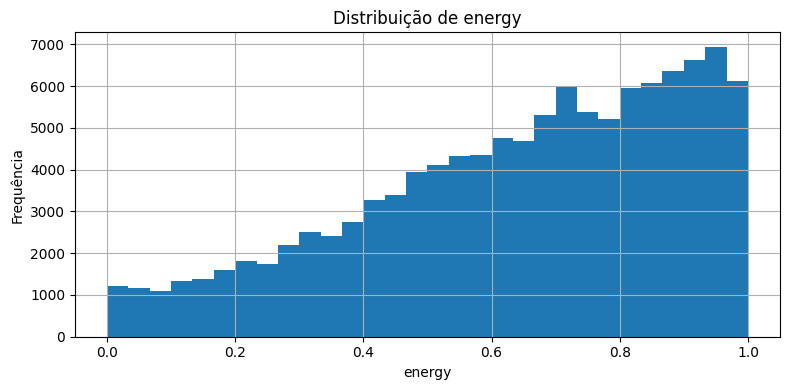

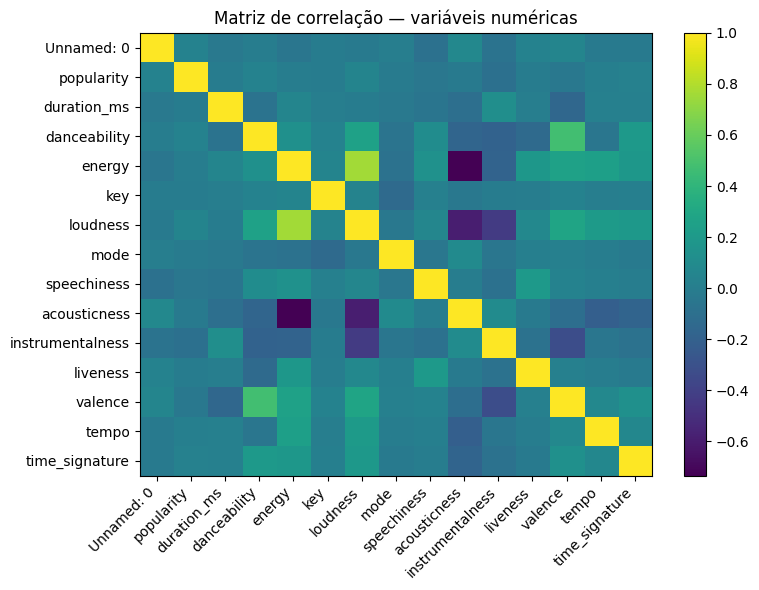

In [6]:
# Visualizações exploratórias básicas
# O grupo deve adaptar as colunas às características do dataset.

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=30)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)

    if numericas.shape[1] < 2:
        print("Não há pelo menos duas variáveis numéricas para calcular correlação.")
        return

    corr = numericas.corr()

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Matriz de correlação — variáveis numéricas")
    plt.tight_layout()
    plt.show()

# Exemplos de uso:
plot_distribuicao_numerica(df, "energy")
#plot_contagem_categorica(df, "[COLUNA_CATEGORICA]")
plot_matriz_correlacao(df)


## 2.2 Análise visual — interpretação

[INSERIR INTERPRETAÇÃO DOS GRÁFICOS]

A interpretação deve evitar apenas descrever o óbvio. Procure responder:

- Há concentração de valores?
- Há valores extremos?
- Há categorias muito raras?
- Há desbalanceamento?
- Os padrões observados afetam a tarefa de mineração?
- Alguma visualização sugere risco associado às diretrizes escolhidas?

> Não invente conclusões. Toda afirmação empírica deve estar apoiada em uma tabela, gráfico ou cálculo executado no notebook.


In [7]:
# Detecção simples de outliers em variáveis numéricas usando IQR
# Esta função é um exemplo. O grupo deve avaliar se o critério faz sentido para cada atributo.

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

# Exemplo de uso:
outliers = detectar_outliers_iqr(df, "duration_ms")
display(outliers.head())


Coluna: duration_ms
Q1: 174066.0
Q3: 261506.0
IQR: 87440.0
Limite inferior: 42906.0
Limite superior: 392666.0
Número de outliers: 5617


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
253,253,0I0l2Oo5zjpCEphpDJL0Pm,Motohiro Hata,言ノ葉,Rain - Long Ver.,44,447306,False,0.588,0.6040,...,-7.602,1,0.0240,0.3430,0.000069,0.2520,0.351,92.020,4,acoustic
650,650,6ad7bQ48TlqAgebCExUJVe,Ichiko Aoba,0,いきのこり●ぼくら,52,406103,False,0.592,0.0833,...,-16.517,0,0.0835,0.9460,0.079100,0.0941,0.205,143.243,4,acoustic
752,752,1TRIYxcVJYPki5AX2hZzZT,Luther Allison,Bad News Is Coming,Bad News Is Coming,52,445533,False,0.639,0.4960,...,-6.844,0,0.0375,0.7130,0.254000,0.0545,0.467,140.394,3,acoustic
851,851,5fomS2mZjvxxJ2iVH3fosc,John Elliott,All Too Well (Jake's Version),All Too Well - Jake's Version,33,578064,False,0.685,0.4830,...,-9.082,1,0.0253,0.0772,0.000061,0.1130,0.331,93.032,4,acoustic
896,896,0xOIqJadsikka2so1zhghO,Harley Poe,Horrorful,Alone in the Dark Mansion of Madness,26,403911,True,0.335,0.6960,...,-9.472,0,0.0307,0.6420,0.000000,0.1200,0.403,95.240,4,acoustic


## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes em [COLUNA] | Não se aplica | Não se aplica | Não se aplica |
| Duplicatas | tamanho do dataset > quantidade de track_id distintos | Remover| às vezes, a música aparece 2x quando ela tem 2 ou mais gêneros musicais em que ela se encaixa. Deixamos apenas 1 por pessoa |
| Outliers em duration_ms | Visualmente notório | Remover outliers | Ruidos brancos, jingles de 10-15 segundos e coisas assim são prejudiciais e não nos fornecem dados úteis |
| Categorias raras | Não se aplica (eu acho) | Não se aplica (eu acho) | Não se aplica (eu acho) |
| Atributos sensíveis ou identificadores | o atribuito chama "ID" | remover | Ele já não seria útil por ser string de qualquer jeito |

### Observação sobre responsabilidade

[EXPLICAR SE ALGUMA DECISÃO DE PREPARAÇÃO TEM IMPLICAÇÕES PARA AS DIRETRIZES ESCOLHIDAS]

Exemplo:

> A remoção de um atributo sensível pode reduzir risco de exposição indevida, mas também pode dificultar a análise de disparidades entre grupos. Essa decisão deve ser justificada com cuidado.


In [8]:
# Exemplo de preparação dos dados
# Esta célula é propositalmente genérica.
# O grupo deve adaptar de acordo com o dataset e a tarefa.

def preparar_dados_basico(
    df: pd.DataFrame,
    colunas_remover=None,
    imputar_numericas=True,
    imputar_categoricas=True
) -> pd.DataFrame:
    df_prep = df.copy()

    # 1. Remover duplicatas exatas
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas explicitamente marcadas como irrelevantes ou identificadoras
    if colunas_remover is None:
        colunas_remover = [
            "[track_id]",
            "[artists]",
            "[album_name]"
        ]

    colunas_existentes = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_existentes)

    # 3. Exemplo de tratamento simples de nulos
    # Atenção: imputação deve ser justificada no texto.
    if imputar_numericas:
        for col in df_prep.select_dtypes(include=np.number).columns:
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    if imputar_categoricas:
        for col in df_prep.select_dtypes(include=["object", "category"]).columns:
            df_prep[col] = df_prep[col].fillna("desconhecido")

    return df_prep

# Exemplo de uso:
df_prep = preparar_dados_basico(df, colunas_remover=["track_id",
            "artists",
            "album_name",
            "popularity",
            "track_name",
            "track_genre"
            "Unnamed: 0"
            ])
display(df_prep.head())


,Unnamed: 0,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [9]:
def one_hot_encode_key_mode_time_signature(
    df: pd.DataFrame,
    drop_original: bool = True,
    prefix_sep: str = "_"
) -> pd.DataFrame:
    """
    One-hot encodes the categorical columns 'key', 'mode' and 'time_signature'.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    drop_original : bool, default True
        If True, remove the original categorical columns after encoding.
    prefix_sep : str, default "_"
        Separator used between column name and category value.

    Returns
    -------
    pd.DataFrame
        DataFrame with one-hot encoded features.
    """
    cols = ["key", "mode", "time_signature"]
    missing = [col for col in cols if col not in df.columns]
    if missing:
        raise KeyError(f"Colunas não encontradas para one-hot encoding: {missing}")

    df_encoded = pd.get_dummies(
        df,
        columns=cols,
        prefix=cols,
        prefix_sep=prefix_sep,
        dummy_na=False
    )

    if not drop_original:
        # get_dummies already drops originals, so restore them if necessary
        df_encoded = df_encoded.join(df[cols])

    return df_encoded

# Eu ainda não testei essa função, mas o exemplo de uso é esse aqui:
df_prep = one_hot_encode_key_mode_time_signature(df_prep)
display(df_prep.head())

,Unnamed: 0,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,...,key_9,key_10,key_11,mode_0,mode_1,time_signature_0,time_signature_1,time_signature_3,time_signature_4,time_signature_5
0,0,230666,False,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,...,False,False,False,True,False,False,False,False,True,False
1,1,149610,False,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,...,False,False,False,False,True,False,False,False,True,False
2,2,210826,False,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,...,False,False,False,False,True,False,False,False,True,False
3,3,201933,False,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,...,False,False,False,False,True,False,False,True,False,False
4,4,198853,False,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,...,False,False,False,False,True,False,False,False,True,False


In [10]:
def bools_para_float(df: pd.DataFrame, inplace: bool = False) -> pd.DataFrame:
    """
    Converte colunas booleanas de um DataFrame em float, usando 0.0 para False e 1.0 para True.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    inplace : bool, default False
        Se True, modifica o DataFrame original; caso contrário, retorna uma cópia.

    Returns
    -------
    pd.DataFrame
        DataFrame com colunas booleanas convertidas para float.
    """
    df_out = df if inplace else df.copy()
    bool_cols = df_out.select_dtypes(include="bool").columns

    if len(bool_cols) > 0:
        df_out[bool_cols] = df_out[bool_cols].astype(float)

    return df_out

# Exemplo de uso:
df_prep = bools_para_float(df_prep)
display(df_prep.head())

,Unnamed: 0,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,...,key_9,key_10,key_11,mode_0,mode_1,time_signature_0,time_signature_1,time_signature_3,time_signature_4,time_signature_5
0,0,230666,0.0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,149610,0.0,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2,210826,0.0,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,3,201933,0.0,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,4,198853,0.0,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [11]:
def z_normalizar_df(df: pd.DataFrame, colunas_incluir=None) -> pd.DataFrame:
    """
    Z-normaliza as colunas numéricas de um DataFrame.
    Se colunas_incluir for None, normaliza todas as colunas numéricas.
    Retorna uma cópia do DataFrame com as colunas selecionadas padronizadas.
    """
    df_norm = df.copy()

    if colunas_incluir is None:
        colunas_incluir = df_norm.select_dtypes(include=np.number).columns.tolist()

    colunas_incluir = [col for col in colunas_incluir if col in df_norm.columns]

    if len(colunas_incluir) == 0:
        return df_norm

    medias = df_norm[colunas_incluir].mean()
    desvios = df_norm[colunas_incluir].std(ddof=0).replace(0, 1)

    df_norm[colunas_incluir] = (df_norm[colunas_incluir] - medias) / desvios

    return df_norm

# Exemplo de uso:
df_prep_norm = z_normalizar_df(df_prep)
display(df_prep_norm.head())

,Unnamed: 0,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,...,key_9,key_10,key_11,mode_0,mode_1,time_signature_0,time_signature_1,time_signature_3,time_signature_4,time_signature_5
0,-1.732036,0.024575,-0.305767,0.629244,-0.717148,0.300828,0.551848,-0.850202,-0.504109,0.758743,...,-0.331918,-0.264538,-0.297721,1.326281,-1.326281,-0.03784,-0.092782,-0.296200,0.345500,-0.127586
1,-1.732005,-0.730859,-0.305767,-0.845908,-1.889980,-1.784744,-0.078993,1.831732,-0.504094,-0.591211,...,-0.331918,-0.264538,-0.297721,-0.753988,0.753988,-0.03784,-0.092782,-0.296200,0.345500,-0.127586
2,-1.731975,-0.160332,-0.305767,-0.742186,-1.122669,-0.293288,-0.273826,-0.315499,-0.504112,-0.507167,...,-0.331918,-0.264538,-0.297721,-0.753988,0.753988,-0.03784,-0.092782,-0.296200,0.345500,-0.127586
3,-1.731944,-0.243214,-0.305767,-1.733304,-2.312994,-2.039252,-0.457309,1.774593,-0.503883,-0.428376,...,-0.331918,-0.264538,-0.297721,-0.753988,0.753988,-0.03784,-0.092782,3.376099,-2.894359,-0.127586
4,-1.731914,-0.271919,-0.305767,0.295030,-0.788711,-0.282750,-0.303145,0.463399,-0.504112,-0.686285,...,-0.331918,-0.264538,-0.297721,-0.753988,0.753988,-0.03784,-0.092782,-0.296200,0.345500,-0.127586


## 2.4 Justificativa da preparação dos dados
Todas as colunas com string foram removidas porque elas não servem para os algoritmos de agrupamento.
Não há valores ausentes.
Variáveis categóricas foram mantidas, desde que não fossem string.
Houve z-normalização.
Houve remoção de outliers em duration_ms.
Risco de perda de informação, mas não é significativo.
//Falta escrever como se relacionam com as diretrizes

Explique:

- quais colunas foram removidas e por quê;
- como valores ausentes foram tratados;
- como variáveis categóricas foram tratadas;
- se houve normalização, discretização ou codificação;
- se houve remoção de outliers;
- quais riscos essas decisões introduzem;
- como essas decisões se relacionam às diretrizes escolhidas.

> A preparação dos dados não deve ser apenas uma sequência de comandos. Toda decisão relevante precisa de justificativa técnica.


## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** [EXEMPLO: propor estratégias de limpeza, transformação e preparação dos dados para a tarefa de mineração]

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro 
**Data de acesso:** 17/05/2026
**Link da conversa:** (https://gemini.google.com/share/982c18360f57)

#### Prompt principal — baseline

```text
Tenho um dataset com as seguintes colunas: 'Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre'.

A tarefa de mineração é agrupamento.
Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa.
```

#### Síntese da resposta da LLM

Para o Data Understanding:

- visualizar histograma das variáveis numéricas para tentar entender a distribuição delas;
- analisar a escala das variáveis numericas, visto que a disparidade de escala pode ser um problema grande na hora de tentar rodar um algoritmo de agrupamento;
- gerar uma matriz de correlação para avaliar colinearidades;
- gerar boxplots para analisar outliers.

Para o Data Preparation:

- Descartar Unnamed;
- Remover duplicatas com mesmo track_id;
- Remover as colunas em formato string pois "os algoritmos de clusterização normalmente não lidam com texto";
- Salvar "track_genre" em uma outra tabela, antes de remover, pois isso será útil para avaliar os resultados;
- Converter duration_ms para minutos para facilitar interpretabilidade;
- Converter key, mode e time_signature para One-Hot Encoding ou remover todas elas;

- Fazer uma z-normalização dos dados com Standard Scaler
- Sugeriu fazer redução de dimensionalidade (colocou como opcional), mas não mencionou diretamente como fazê-lo.


---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro 
**Data de acesso:** 17/05/2026 
**Link da conversa:** (https://gemini.google.com/share/220f80d6832a)

#### Prompt principal — guiado

```text
Tenho um dataset com as seguintes colunas: 'Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre'.

A tarefa de mineração é agrupamento.
Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa.

Considere explicitamente as seguintes diretrizes de IA responsável na sua formulação:

1. Monitoramento e Avaliação: Como não existe uma resposta correta prévia em problemas de clusterização não supervisionados, avalie a qualidade dos agrupamentos de forma criteriosa, sugerindo e justificando métricas quantitativas (como Silhouette Score) e propondo comparações entre algoritmos.

2. Explicabilidade: A clusterização pode gerar agrupamentos difíceis de interpretar. Portanto, justifique os parâmetros e exija descrições semânticas claras para cada cluster, baseando-se nas características acústicas predominantes, para que façam sentido como perfis musicais reais.

Ao sugerir a preparação, indique:
- possíveis atributos sensíveis, se houver;
- riscos de viés ou perda de informação;
- decisões que devem ser documentadas;
- transformações necessárias;
- limitações e trade-offs.
```

#### Síntese da resposta da LLM

Para Data Understanding:

Ele fez uma análise um pouco mais detalhada de cada variável, analisando e "pré-sugerindo" / justificando o que fazer com elas

- remover Unnamed;
- descartar identificadores (track_id, artists, album_name, track_name), mas reter em uma tabela para análise futura;
- padronizar as ordens de grandeza: duration_ms, loudness, tempo
- Fazer One-Hot Ecoding para key, mode, time_signature, track_genre, explicit (avisou que track_genre pode enviesar o modelo se for para agrupar por gênero musical)
- Falou que popularidade pode ofuscar a similaridade sonora agrupando apenas "hits" vs "fracassos comerciais", mas não deixou claro o que fazer com essa informação [nesta parte da resposta].

Para Data Preparation:

O modelo foi dando instruções diretas e explicando-as rapidamente:

- Remover track_genre e popularity;
- Considerar track_genre e artist como atributos sensíveis;
- z-normalização em todas as variáveis;
- Mencionou reduzir a dimensionalidade, mas também falou do trade-off da redução da dimensionalidade com a perda da explicabilidade. Sugeriu não reduzir por enquanto.
- Ficar atendo a outliers em duration e removê-los.

Além disso, o modelo fez uma série de sugestões para seguir as diretrizes:

- Usar Silhouette Score e Davies-Bouldin Index como métricas quantitativas de avaliação;
- Comparar resultados do K-Means, Clusterização Hierárquica e DBSCAN
- Fazer uma "auditoria semântica" após o algoritmo rodar e a solução só será validada se fizer sentido com os dados reais.


## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo |
|---|---|---|---|
| Tratamento de nulos | Não se aplica | Não se aplica | Não se aplica |
| Tratamento de outliers | Remover outliers em duration_ms | Remover outliers em duration_ms | [ACEITAR] |
| Atributos sensíveis | Remover (mas não mencionou que são sensíveis) | Remover | [ACEITAR] |
| Codificação de variáveis | One-Hot Encoding para key (tom), mode (maior/menor) e time_signature | One-Hot Encoding para key, mode, time_signature, track_genre, explicit | [ACEITAR Baseline] |
| Redução de dimensionalidade | Mencinou e sugeriu fazer | Mencionou e também falou de tradeoff com explicabilidade | REJEITAR |
| Justificativa técnica | [ANALISAR] | [ANALISAR] | [DECISÃO] |
| Riscos e limitações | [ANALISAR] | [ANALISAR] | [DECISÃO] |

### Análise crítica

Neste caso, ambos os modelos foram excelentes. Mesmo o modelo baseline teve preocupação com interpretabilidade.
É válido lembrar que, como estou com minha conta pessoal do Gemini, ele pode ter "aprendido" essa preocupação após o TP1.
Algumas sugestões corretas: z-normalização e remoção de outliers.
Nada estava incompleto ou tecnicamente errado. Contudo, é válido mencionar que a trilha B sugeriu comparar diversos métodos de clusterização, o que pode fazer sentido para a diretriz de monitoramento e avaliação, mas que pode chegar a ser inviável pelo tamanho do dataset.
Foram aceitas as sugestões citadas com corretas.
Foi rejeitada redução de dimensionalidade.
Nesta sessão, nada foi corrigido, apenas aceito ou rejeitado.


A análise deve deixar claro:

- o que a LLM sugeriu corretamente;
- o que estava incompleto;
- o que estava tecnicamente errado;
- o que foi aceito;
- o que foi rejeitado;
- o que foi corrigido pelo grupo.


# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de padrões frequentes, a modelagem pode envolver, por exemplo:

- Apriori;
- FP-Growth;
- Eclat;
- regras de associação.

Para outros TPs, substituir pelos algoritmos pertinentes, como algoritmos de agrupamento ou classificação.

O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** [EXEMPLO: propor algoritmos, parâmetros, métricas e estratégia de avaliação para a tarefa]

---

### Trilha A — baseline

**Modelo utilizado:** [INSERIR MODELO]  
**Data de acesso:** [INSERIR DATA]  
**Link da conversa:** [INSERIR LINK DA CONVERSA]

#### Prompt principal — baseline

```text
[INSERIR PROMPT BASELINE]

Exemplo:
Com base no dataset [NOME] e na tarefa [TAREFA], proponha uma estratégia de modelagem.
Indique algoritmos, parâmetros iniciais, métricas de avaliação e como comparar resultados.
```

#### Síntese da resposta da LLM

[INSERIR SÍNTESE]

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** [INSERIR MODELO]  
**Data de acesso:** [INSERIR DATA]  
**Link da conversa:** [INSERIR LINK DA CONVERSA]

#### Prompt principal — guiado

```text
[INSERIR PROMPT GUIADO]

Exemplo:
Com base no dataset [NOME] e na tarefa [TAREFA], proponha uma estratégia de modelagem.

Considere explicitamente as diretrizes:
1. [DIRETRIZ 1]
2. [DIRETRIZ 2]

Na resposta, indique:
- algoritmos adequados;
- parâmetros iniciais;
- métricas de avaliação;
- riscos metodológicos;
- impacto das diretrizes nas escolhas;
- trade-offs entre desempenho, interpretabilidade, custo computacional e qualidade da solução.
```

#### Síntese da resposta da LLM

[INSERIR SÍNTESE]


## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
|---|---|---|---|---|
| Algoritmos sugeridos | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Parâmetros sugeridos | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Métricas sugeridas | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Preparação exigida | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Interpretabilidade | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Custo computacional | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Riscos ou limitações | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Aderência às diretrizes | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |

### Síntese

[INSERIR ANÁLISE COMPARATIVA]

A comparação deve destacar evidências, não impressões vagas.


## 3.3 Template de modelagem para padrões frequentes

Use esta subseção se o TP atual envolver mineração de padrões frequentes. Caso o TP atual seja de agrupamento ou classificação, esta subseção pode ser removida ou mantida como referência não executada.

> **Atenção:** suporte, confiança e lift devem ser interpretados no contexto do dataset. Valores de suporte muito baixos podem gerar muitas regras pouco úteis; valores muito altos podem ocultar padrões relevantes.


In [12]:
# Exemplo de preparação para mineração de padrões frequentes
# Use esta célula apenas se o TP atual for de padrões frequentes.
# Para classificação ou agrupamento, substituir por uma preparação adequada.

def gerar_transacoes_de_coluna(df: pd.DataFrame, coluna: str, separador: str = ",") -> list:
    # Gera uma lista de transações a partir de uma coluna textual.
    # Exemplo: "leite, pão, manteiga" -> ["leite", "pão", "manteiga"]
    transacoes = []

    for valor in df[coluna].dropna():
        itens = [
            item.strip().lower()
            for item in str(valor).split(separador)
            if item.strip()
        ]

        if len(itens) > 0:
            transacoes.append(itens)

    return transacoes

# Exemplo de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# print(f"Número de transações: {len(transacoes)}")
# print(transacoes[:5])


In [13]:
# Exemplo de execução de Apriori e FP-Growth com mlxtend
# Esta célula é semi-funcional e depende da instalação da biblioteca mlxtend.
# O grupo deve ajustar suporte, confiança e métrica conforme o problema.

def executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada.")
        print("Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_apriori = apriori(
        df_transacoes,
        min_support=min_support,
        use_colnames=True
    )
    regras_apriori = association_rules(
        itemsets_apriori,
        metric="confidence",
        min_threshold=min_confidence
    )
    tempo_apriori = time.time() - inicio

    resultados["Apriori"] = {
        "itemsets": itemsets_apriori,
        "regras": regras_apriori,
        "tempo": tempo_apriori
    }

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(
        df_transacoes,
        min_support=min_support,
        use_colnames=True
    )
    regras_fpgrowth = association_rules(
        itemsets_fpgrowth,
        metric="confidence",
        min_threshold=min_confidence
    )
    tempo_fpgrowth = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo": tempo_fpgrowth
    }

    return resultados

# Exemplo de uso:
# resultados = executar_padroes_frequentes(
#     transacoes,
#     min_support=0.05,
#     min_confidence=0.6
# )


In [14]:
# Resumo dos resultados de mineração de padrões frequentes.
# Esta célula não inventa resultados; ela apenas resume o que foi executado.

def resumir_resultados_padroes(resultados):
    if resultados is None:
        print("Nenhum resultado disponível.")
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo"], 4),
            "suporte_minimo_observado": itemsets["support"].min() if len(itemsets) > 0 else np.nan,
            "suporte_maximo_observado": itemsets["support"].max() if len(itemsets) > 0 else np.nan,
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
# resumo_modelagem = resumir_resultados_padroes(resultados)
# display(resumo_modelagem)


In [15]:
# Exemplo de variação de parâmetros
# Útil para verificar se os resultados são sensíveis às escolhas de suporte e confiança.

def testar_parametros_padroes(transacoes, suportes, confiancas):
    linhas = []

    for sup in suportes:
        for conf in confiancas:
            resultados = executar_padroes_frequentes(
                transacoes,
                min_support=sup,
                min_confidence=conf
            )

            resumo = resumir_resultados_padroes(resultados)

            if not resumo.empty:
                resumo["min_support"] = sup
                resumo["min_confidence"] = conf
                linhas.append(resumo)

    if len(linhas) == 0:
        return pd.DataFrame()

    return pd.concat(linhas, ignore_index=True)

# Exemplo de uso:
# grade_resultados = testar_parametros_padroes(
#     transacoes,
#     suportes=[0.01, 0.03, 0.05],
#     confiancas=[0.5, 0.6, 0.7]
# )
# display(grade_resultados)


## 3.4 Template de modelagem para agrupamento

Use esta subseção se o TP atual envolver agrupamento. Caso contrário, remova ou deixe claro que ela não foi utilizada.

> **Atenção:** em agrupamento, não há rótulo verdadeiro na maioria dos casos. A avaliação deve combinar métricas internas, análise visual quando possível e interpretação substantiva dos grupos.


In [16]:
# Exemplo genérico para agrupamento com K-Means
# O grupo deve adaptar features, normalização e métricas conforme o dataset.

def preparar_matriz_numerica_para_modelagem(df: pd.DataFrame, colunas=None) -> pd.DataFrame:
    if colunas is None:
        X = df.select_dtypes(include=np.number).copy()
    else:
        X = df[colunas].copy()

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    return X

def executar_kmeans_basico(X: pd.DataFrame, n_clusters=3):
    try:
        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans
        from sklearn.metrics import silhouette_score, davies_bouldin_score
    except ImportError:
        print("Biblioteca scikit-learn não instalada.")
        return None

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    modelo = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    labels = modelo.fit_predict(X_scaled)

    resultados = {
        "modelo": modelo,
        "labels": labels,
        "silhouette": silhouette_score(X_scaled, labels) if n_clusters > 1 else np.nan,
        "davies_bouldin": davies_bouldin_score(X_scaled, labels) if n_clusters > 1 else np.nan,
        "inertia": modelo.inertia_
    }

    return resultados

# Exemplo de uso:
# X = preparar_matriz_numerica_para_modelagem(df_prep)
# resultados_cluster = executar_kmeans_basico(X, n_clusters=3)
# resultados_cluster


## 3.5 Template de modelagem para classificação

Use esta subseção se o TP atual envolver classificação. Caso contrário, remova ou deixe claro que ela não foi utilizada.

> **Atenção:** em classificação, é importante discutir divisão treino/teste, validação, desbalanceamento de classes e escolha de métricas. Acurácia isolada pode ser inadequada em bases desbalanceadas.


In [17]:
# Exemplo genérico para classificação
# O grupo deve adaptar TARGET_COLUMN, tratamento de categóricas e métricas.

def executar_classificacao_basica(df: pd.DataFrame, target_col: str):
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.pipeline import Pipeline
        from sklearn.compose import ColumnTransformer
        from sklearn.preprocessing import OneHotEncoder, StandardScaler
        from sklearn.impute import SimpleImputer
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import classification_report, confusion_matrix
    except ImportError:
        print("Biblioteca scikit-learn não instalada.")
        return None

    if target_col not in df.columns:
        raise ValueError(f"Coluna-alvo não encontrada: {target_col}")

    X = df.drop(columns=[target_col])
    y = df[target_col]

    colunas_numericas = X.select_dtypes(include=np.number).columns.tolist()
    colunas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    preprocessador = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), colunas_numericas),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), colunas_categoricas)
        ]
    )

    modelo = Pipeline([
        ("preprocessamento", preprocessador),
        ("classificador", RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None
    )

    inicio = time.time()
    modelo.fit(X_train, y_train)
    tempo_treino = time.time() - inicio

    y_pred = modelo.predict(X_test)

    print(f"Tempo de treino: {tempo_treino:.4f} segundos")
    print("\nRelatório de classificação:")
    print(classification_report(y_test, y_pred))

    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "modelo": modelo,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "tempo_treino": tempo_treino
    }

# Exemplo de uso:
# resultados_classificacao = executar_classificacao_basica(df_prep, TARGET_COLUMN)


## 3.6 Resultados preliminares da modelagem

[INSERIR RESULTADOS OBTIDOS APÓS EXECUÇÃO DO CÓDIGO]

Inclua tabelas e comentários sobre os resultados relevantes para a tarefa:

### Se a tarefa for padrões frequentes

- número de padrões encontrados;
- número de regras geradas;
- suporte, confiança e lift;
- tempo de execução;
- redundância e interpretabilidade das regras.

### Se a tarefa for agrupamento

- número de clusters;
- métricas internas, como Silhouette e Davies-Bouldin;
- tamanho dos grupos;
- interpretação dos clusters;
- estabilidade com diferentes parâmetros.

### Se a tarefa for classificação

- métricas como acurácia, precisão, revocação, F1-score e matriz de confusão;
- análise de classes minoritárias;
- overfitting ou underfitting;
- interpretabilidade e possíveis vieses.

### Atenção

Não conclua que um algoritmo é “melhor” apenas por uma métrica isolada.

Uma comparação adequada deve considerar:

- qualidade da solução;
- interpretabilidade;
- custo computacional;
- estabilidade;
- adequação ao problema;
- relação com as diretrizes escolhidas.


## 3.7 Análise da aderência às diretrizes

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
|---|---|---|---|---|
| [DIRETRIZ 1] | [PREENCHER] | [PREENCHER] | [SIM/NÃO/PARCIALMENTE] | [JUSTIFICAR] |
| [DIRETRIZ 2] | [PREENCHER] | [PREENCHER] | [SIM/NÃO/PARCIALMENTE] | [JUSTIFICAR] |

### Discussão

[INSERIR DISCUSSÃO]

A resposta deve ser específica. Exemplos de boa análise:

- “A Trilha B sugeriu registrar parâmetros e versões dos experimentos, o que melhora rastreabilidade.”
- “A Trilha B sugeriu avaliar desempenho por subgrupos, o que é pertinente à diretriz de justiça e viés.”
- “A Trilha B recomendou um algoritmo mais interpretável, mas com possível perda de desempenho.”
- “Apesar de mencionar privacidade, a Trilha B não propôs nenhuma alteração concreta no pipeline.”

Evite frases vagas como:

- “A resposta guiada foi mais responsável.”
- “A LLM considerou melhor as diretrizes.”
- “O resultado foi mais ético.”


# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

[INSERIR ANÁLISE DOS RESULTADOS]

A análise deve responder:

- Os padrões, clusters, classificações ou resultados encontrados fazem sentido?
- Eles são relevantes para o problema de negócio?
- Há resultados triviais, redundantes ou pouco úteis?
- O desempenho obtido é adequado?
- As métricas usadas são compatíveis com a tarefa?
- Há limitações nos dados ou na modelagem que afetam a conclusão?

> Se os experimentos não produziram bons resultados, isso também é um resultado válido, desde que seja analisado tecnicamente.


## 4.2 Avaliação das sugestões da LLM

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
|---|---|---|---|
| [SUGESTÃO 1] | Baseline | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |
| [SUGESTÃO 2] | Guiada | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |
| [SUGESTÃO 3] | Guiada | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
|---|---|---|---|
| [ERRO/OMISSÃO] | [A/B] | [EXPLICAR] | [EXPLICAR] |
| [ERRO/OMISSÃO] | [A/B] | [EXPLICAR] | [EXPLICAR] |

### Comentário crítico

[INSERIR COMENTÁRIO SOBRE A QUALIDADE DAS RESPOSTAS DA LLM]


## 4.3 Comparação final entre as trilhas

| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
|---|---|---|---|
| Utilidade prática | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Correção técnica | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Clareza das justificativas | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Aderência às diretrizes | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da modelagem | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da avaliação | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Riscos não tratados | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Conclusão comparativa

[INSERIR CONCLUSÃO]

A conclusão deve indicar se a explicitação das diretrizes:

- produziu mudanças concretas;
- produziu apenas mudanças superficiais;
- não produziu diferença relevante;
- introduziu novos trade-offs;
- ajudou a identificar limitações ou riscos;
- levou o grupo a alterar decisões técnicas.


## 4.4 Trade-offs identificados

| Trade-off | Evidência | Decisão do grupo |
|---|---|---|
| Interpretabilidade × desempenho | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Privacidade × utilidade dos dados | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Custo computacional × qualidade da solução | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Simplicidade × completude da análise | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Justiça/viés × disponibilidade de atributos | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |

### Discussão

[INSERIR DISCUSSÃO SOBRE OS TRADE-OFFS]

Nem todo trade-off estará presente em todo trabalho. O grupo deve discutir apenas os que forem pertinentes ao dataset e à tarefa.


## 4.5 Considerações finais da Fase 2

[INSERIR CONSIDERAÇÕES FINAIS]

A conclusão da Fase 2 deve responder:

1. A LLM ajudou em quais partes do trabalho?
2. Em quais partes a LLM errou ou foi superficial?
3. A Trilha B foi de fato diferente da Trilha A?
4. As diretrizes escolhidas tiveram efeito concreto?
5. Quais sugestões serão levadas para a Fase 3?
6. Quais sugestões serão descartadas?
7. O que ainda precisa ser implementado ou corrigido na versão final?

### Próximos passos para a Fase 3

- [ ] Corrigir limitações identificadas nas respostas da LLM.
- [ ] Consolidar a preparação dos dados.
- [ ] Executar modelagem final.
- [ ] Avaliar resultados de forma mais completa.
- [ ] Integrar análise comparativa baseline × guiada × solução final.
- [ ] Revisar documentação e reprodutibilidade.


# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] comprovação de que o dataset atende às restrições mínimas;
- [ ] descrição do problema de negócio;
- [ ] descrição das colunas;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] justificativa das diretrizes;
- [ ] hipótese experimental;
- [ ] Trilha A — baseline;
- [ ] Trilha B — guiada;
- [ ] modelo utilizado em cada trilha;
- [ ] data de acesso em cada trilha;
- [ ] links das conversas;
- [ ] prompts principais;
- [ ] síntese crítica das respostas;
- [ ] comparação entre baseline e guiada;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] análise de erros e limitações da LLM;
- [ ] conexão com Business Understanding;
- [ ] conexão com Data Understanding & Preparation;
- [ ] conexão com Modeling;
- [ ] conexão com Evaluation;
- [ ] considerações finais e próximos passos.


# 6. Referências

[INSERIR REFERÊNCIAS USADAS PELO GRUPO]

Exemplos de referências possíveis:

- documentação do dataset;
- materiais da disciplina;
- documentação das bibliotecas usadas;
- referências sobre CRISP-DM;
- referências sobre IA responsável;
- referências sobre algoritmos aplicados.

> As referências devem apoiar decisões técnicas e metodológicas. Não use referências apenas de forma decorativa.


# Apêndice A — Modelo de registro de interações com LLM

Esta seção é opcional, mas recomendada para organizar evidências.

| ID | Trilha | Subtarefa | Modelo | Data | Link | Prompt resumido | Decisão do grupo |
|---|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B1 | Guiada | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A2 | Baseline | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B2 | Guiada | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A3 | Baseline | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B3 | Guiada | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |


In [18]:
# Apêndice B — Estrutura opcional para registrar prompts e respostas de forma organizada
# Esta estrutura pode ajudar o grupo a manter rastreabilidade.
# Evite inserir respostas muito longas no notebook; prefira sínteses críticas e links das conversas.

registros_llm = [
    {
        "id": "A1",
        "trilha": "baseline",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B1",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    }
]

df_registros_llm = pd.DataFrame(registros_llm)
display(df_registros_llm)


,id,trilha,subtarefa,modelo,data,link_conversa,prompt_resumido,sintese_resposta,decisao_grupo,comentario_critico
0,A1,baseline,Business Understanding,[INSERIR MODELO],[INSERIR DATA],[INSERIR LINK DA CONVERSA],[INSERIR RESUMO DO PROMPT],[INSERIR SÍNTESE DA RESPOSTA],[ACEITA/REJEITADA/CORRIGIDA],[INSERIR COMENTÁRIO]
1,B1,guiada,Business Understanding,[INSERIR MODELO],[INSERIR DATA],[INSERIR LINK DA CONVERSA],[INSERIR RESUMO DO PROMPT COM DIRETRIZES],[INSERIR SÍNTESE DA RESPOSTA],[ACEITA/REJEITADA/CORRIGIDA],[INSERIR COMENTÁRIO]
